### Let's implement a simple Rnn with Tensorflow:

### Dataset loading

In [17]:
import pandas as pd
import numpy as np
import os


filepath = "Datasets\\Sequences_Australia_Beer_Production\\ausbeer.csv"
df = pd.read_csv(filepath)
df.describe()


,value
count,218.000000
mean,415.371560
std,85.880662
min,213.000000
25%,379.250000
50%,422.000000
75%,465.750000
max,599.000000


### Dataset Cleaning

In [18]:
df["quarter_str"] = df["index"].str.replace(" ", "")
df["date"] = pd.PeriodIndex(df["quarter_str"], freq="Q").to_timestamp()
df = df.set_index("date")[["value"]]
df.head()

,value
date,
1956-01-01,284
1956-04-01,213
1956-07-01,227
1956-10-01,308
1957-01-01,262


### View the Graphic representation of the series

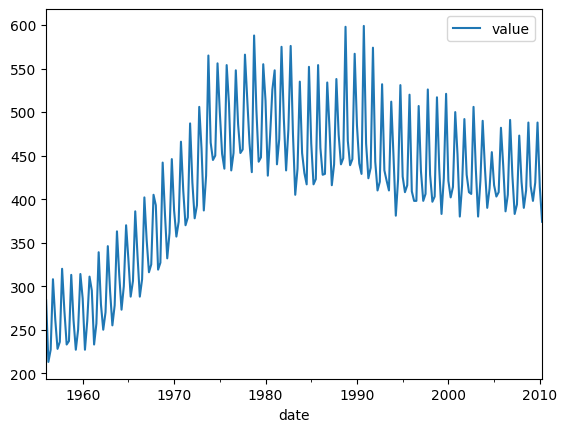

In [19]:
import matplotlib.pyplot as plt
df.plot()
plt.show()

### Training Set and Evaluation Set Splitting

In [20]:
split_info = int(len(df) * 0.9)
train_data = df[:split_info]
test_data = df[split_info:]
print(f"Train data length: {len(train_data)}")
print(f"Test data length: {len(test_data)}")

Train data length: 196
Test data length: 22


### Scaling del training Set:

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_data)

scaled_train = scaler.transform(train_data)
scaled_test = scaler.transform(test_data)
print(scaled_train[:5])

[[-1.45725871]
 [-2.25049995]
 [-2.09408618]
 [-1.18912083]
 [-1.70305177]]


### Dataset Creation

In [22]:
import numpy as np

example = [1, 3, 2, 4, 5, 6, 7, 8, 9]

seq_len, pred_len = 6, 3

def preprocess_dataset(series, seq_len, pred_len):
    X, y = [], []
    # loop until we have enough future values
    for i in range(len(series) - seq_len - pred_len + 1):
        # past window of length seq_len
        X.append(series[i : i + seq_len])
        # next pred_len values
        y.append(series[i + seq_len : i + seq_len + pred_len])
    return np.array(X), np.array(y)

x_train, y_train = preprocess_dataset(scaled_train, seq_len, pred_len)
x_test, y_test = preprocess_dataset(scaled_test, seq_len, pred_len)
print("X:", x_train[:10])
print("y:", y_train[:10])


X: [[[-1.45725871]
  [-2.25049995]
  [-2.09408618]
  [-1.18912083]
  [-1.70305177]
  [-2.08291377]]

 [[-2.25049995]
  [-2.09408618]
  [-1.18912083]
  [-1.70305177]
  [-2.08291377]
  [-1.99353448]]

 [[-2.09408618]
  [-1.18912083]
  [-1.70305177]
  [-2.08291377]
  [-1.99353448]
  [-1.05505189]]

 [[-1.18912083]
  [-1.70305177]
  [-2.08291377]
  [-1.99353448]
  [-1.05505189]
  [-1.59132765]]

 [[-1.70305177]
  [-2.08291377]
  [-1.99353448]
  [-1.05505189]
  [-1.59132765]
  [-2.02705171]]

 [[-2.08291377]
  [-1.99353448]
  [-1.05505189]
  [-1.59132765]
  [-2.02705171]
  [-1.98236207]]

 [[-1.99353448]
  [-1.05505189]
  [-1.59132765]
  [-2.02705171]
  [-1.98236207]
  [-1.13325877]]

 [[-1.05505189]
  [-1.59132765]
  [-2.02705171]
  [-1.98236207]
  [-1.13325877]
  [-1.71422418]]

 [[-1.59132765]
  [-2.02705171]
  [-1.98236207]
  [-1.13325877]
  [-1.71422418]
  [-2.09408618]]

 [[-2.02705171]
  [-1.98236207]
  [-1.13325877]
  [-1.71422418]
  [-2.09408618]
  [-1.83712071]]]
y: [[[-1.99353448

### Model_Creation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = Sequential([
    Input(shape=(10, 8)),       # dichiarazione esplicita dell'input
    SimpleRNN(32),
    Dense(1)
])



c:\Users\david_bbnm\tensorflow\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,187 (4.64 KB)

 Trainable params: 1,187 (4.64 KB)

 Non-trainable params: 0 (0.00 B)

### Model Train

In [24]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='loss', patience=2, restore_best_weights=True)
]


history = rnn_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=1
)


Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1693 - mae: 0.3081 - val_loss: 0.0311 - val_mae: 0.1524
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0561 - mae: 0.1895 - val_loss: 0.0227 - val_mae: 0.1266
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0530 - mae: 0.1804 - val_loss: 0.0316 - val_mae: 0.1503
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0495 - mae: 0.1757 - val_loss: 0.0261 - val_mae: 0.1352
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0482 - mae: 0.1735 - val_loss: 0.0280 - val_mae: 0.1426
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0452 - mae: 0.1660 - val_loss: 0.0297 - val_mae: 0.1498
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0448 - mae: 0.1651 - val_loss: 0.0257 - val_mae: 0.1355
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0469 - mae: 0.1695 - val_loss: 0.0349 - val_mae: 0.1554
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - lo

### Evaluation

MAE (Mean Absolute Error) is the average size of the errors between your model’s predictions and the true values.

An MAE of 1.2 means:

On average, your model’s predictions are off by about 1.2 units from the actual values.

In [25]:

# Valutazione finale
test_loss, test_mae = rnn_model.evaluate(x_test, y_test)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step - loss: 0.0232 - mae: 0.1217
Test Loss (MSE): 0.0232
Test MAE: 0.1217
